# Build an Orders Agent and Read Its Phoenix Traces 🐾📦

Welcome, Agent Explorer! 🐾

This 45-minute tutorial starts with a tiny fake-weather tool.

Then we build an orders agent. First it uses one tool. Then it uses two.

Pause for a quick question before each run. Use Phoenix—the trace detective 🕵️—to see what really happened.

The order data is synthetic classroom data.

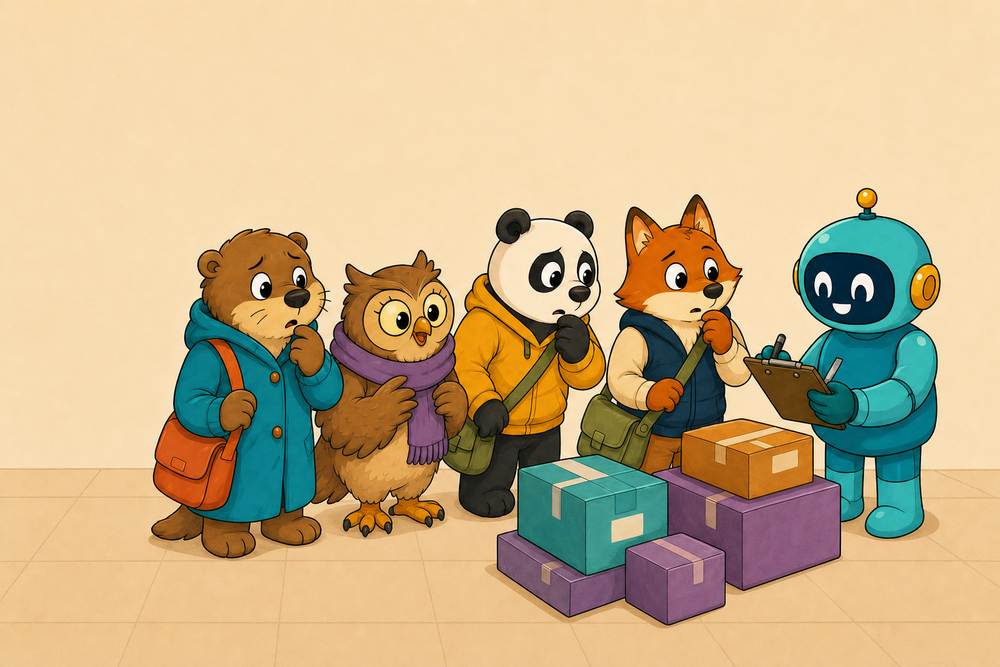

*A tiny order helper is ready to lend a paw.*

## Goal

By the end, you can:

- name an Agent's instructions, model, and tools 🤖
- register normal Python functions as tools
- run grounded questions
- read Phoenix traces for calls and tokens

No magic wand required 🪄—just small steps and curious questions.

## Setup

Run the one collapsed setup cell ▶️.

The workshop environment is already prepared for you.

It imports the helpers, uses your JupyterHub username for the Phoenix project (or your local OS username outside JupyterHub), and turns tracing on once for this notebook.

In [ ]:
import sys
from pathlib import Path


_repository_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "notebooks/workshop_helpers.py").is_file()
)
sys.path.insert(0, str(_repository_root / "notebooks"))

from workshop_helpers import (
    Agent,
    GOOGLE_MODEL,
    InMemoryRunner,
    PROJECT_NAME,
    repository_root,
    run_traced_turn,
)

### Quick check 🤔 — concept check

**Concept check:**

1. Which Phoenix project are your traces entering?

2. What project name did you expect before running the cell?

## Worked Example

We will start with one small, complete weather tool ☔.

Its type hint and docstring explain the tool to the model.

The Seattle result is fixed, so everyone sees the same safe example.

First look at the real Python file. Then see how the Agent instruction and `tools` list make the function available.

In [ ]:
from IPython.display import Code, display


display(Code(filename=str(repository_root / "notebooks/tools_weather.py"), language="python"))

### Build the weather Agent

The function is already written for you.

The Agent is the little decision-maker 🤖. It adds a model and a simple instruction that says when to use the function.

In [ ]:
from tools_weather import get_weather


weather_agent = Agent(
    name="weather_example_agent",
    model=GOOGLE_MODEL,
    instruction=(
        "Use get_weather for every weather fact. "
        "Tell the user the result is simulated and do not invent missing data."
    ),
    tools=[get_weather],
)
weather_runner = InMemoryRunner(agent=weather_agent, app_name="orders_workshop_weather")

### Quick check 🤔 — concept check

**Concept check:**

1. Which parts of get_weather become visible in the model's tool contract?

2. Why do they matter?

### Run the weather trace

Before you run the cell, ask yourself what the trace should show 🔍:

- one `execute_tool` span
- two `call_llm` spans
- the order model → tool → model

Then run the fixed Seattle question in a fresh session and open the named parent trace in Phoenix.

If the trace is different, that is a clue—not a catastrophe!

In [ ]:
await run_traced_turn(
    trace_name="01-weather-demo",
    runner=weather_runner,
    prompt="Do I need an umbrella in Seattle today?",
    session_id="weather-demo-session",
)

### Quick check 🤔 — concept check

**Concept check:**

1. How many execute_tool spans, call_llm spans, and total tokens appear?

2. What does that path tell you?

## Build

Next, look at the two order tools in `tools_order.py` 📦.

The file contains the API details, validation, type hints, and docstrings.

The notebook renders the file and imports the two public functions.

You can focus on how an Agent uses the tools instead of copying REST code into a cell. The boring paperwork is already handled!

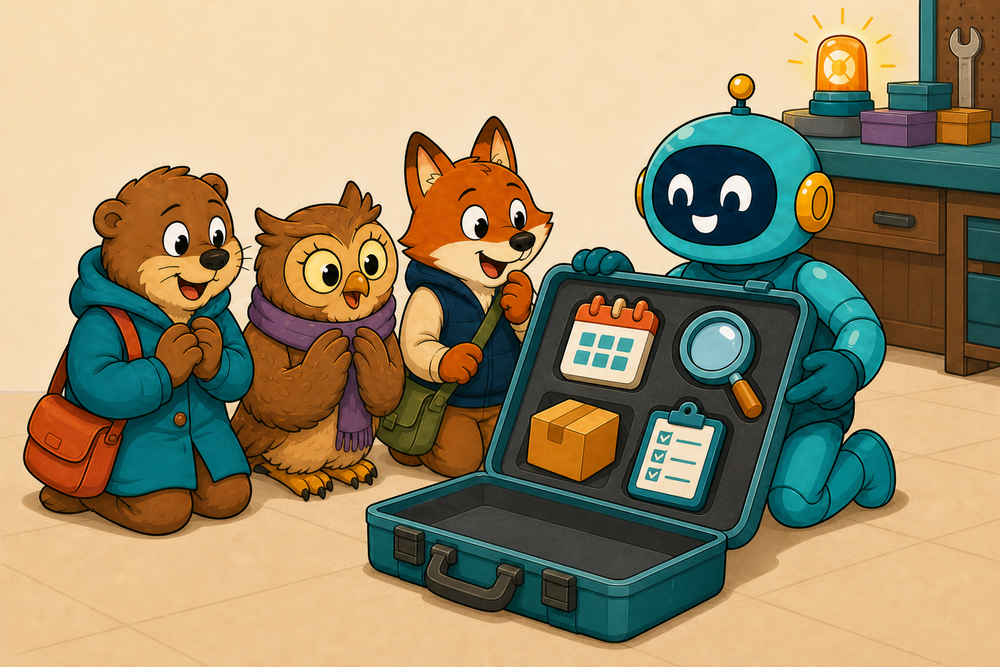

*Tools are the little handles your Agent can reach for.*

The deployed Orders API has interactive [Swagger docs](https://walmart-demo-api-k2yx3oubha-ue.a.run.app/docs). Use them to see the endpoint shapes behind these two tools.

In [ ]:
from inspect import getsource
from IPython.display import Code, display
from tools_order import list_orders

display(Code(data=getsource(list_orders), language="python"))

In [ ]:
from inspect import getsource
from IPython.display import Code, display
from tools_order import get_order

display(Code(data=getsource(get_order), language="python"))

### Quick check 🤔 — concept check

**Concept check:**

1. Which tool discovers order IDs, and which tool is required for item details?

### Configure the orders Agent

Now you will configure the orders Agent 🤖.

Its instruction should say:

- use a tool for every factual order answer
- use `list_orders` with clear, inclusive dates when you do not know an order ID
- use `get_order` before answering item questions
- use only IDs returned by the service
- say when information is missing

Then register both imported functions in the `tools` list.

In [ ]:
orders_agent = Agent(
    name="orders_agent",
    model=GOOGLE_MODEL,
    instruction="""# YOUR TURN: write the grounding instruction described above.""",
    tools=[
        # YOUR TURN: register the two provided order functions.
    ],
)

### Quick check 🤔 — concept check

**Concept check:**

1. Which field explains when to use a capability, and which field makes it available?

### Create the runner

The runner starts a conversation with your Agent.

It connects the Agent to ADK's in-memory session service.

Run this cell once after you finish the instruction and `tools` list.

In [ ]:
orders_runner = InMemoryRunner(
    agent=orders_agent,
    app_name="orders_agent_workshop",
)

## Run 1

### One-tool order list

In this run, the user wants a list of orders 📦.

The question is fixed so we can compare the code with the trace:

“List my orders from July 1 through July 31, 2026. Show each order's ID, date, status, and total.”

Run this turn in a new session named `02-orders-list`.

Then open its trace in Phoenix and answer the concept check below.

In [ ]:
LIST_PROMPT = (
    "List my orders from July 1 through July 31, 2026. "
    "Show each order's ID, date, status, and total."
)

await run_traced_turn(
    trace_name="02-orders-list",
    runner=orders_runner,
    prompt=LIST_PROMPT,
    session_id="orders-list-session",
)

### Quick check 🤔 — concept check

**Concept check:**

1. How many `list_orders` tool executions appear?

2. How many order summaries came back in the tool output?

3. What `start_date` and `end_date` did the model pass?

4. On each `call_llm` span, what are the input-token and output-token counts? What is the trace's total token count?


## Run 2

### List, choose, then inspect details

This time the user wants details about the newest order 🕵️📦.

The question is:

“Find my most recent order from July 1 through July 31, 2026. Tell me its status, total, and every item's name and quantity.”

Run this turn in a different fresh session named `03-orders-latest-details`.

Then open its trace in Phoenix and answer the concept check below.

In [ ]:
DETAIL_PROMPT = (
    "Find my most recent order from July 1 through July 31, 2026. "
    "Tell me its status, total, and every item's name and quantity."
)

await run_traced_turn(
    trace_name="03-orders-latest-details",
    runner=orders_runner,
    prompt=DETAIL_PROMPT,
    session_id="orders-details-session",
)

### Quick check 🤔 — concept check

**Concept check:**

1. How many tool executions and model calls appear?

2. How many order summaries came back from `list_orders`?

3. What order ID entered `get_order`, and how many items came back in its output?

4. On each `call_llm` span, what are the input-token and output-token counts? What is the trace's total token count?


## Trace Investigation

Time to be a Phoenix trace detective 🕵️! Open the named traces and answer these questions from the spans and attributes you can see. Your run may look a little different, and that is useful evidence—not a pop quiz with only one right answer.

### 1. Reconstruct the path 🧩

For each trace, open the parent span and follow its children.

- What sequence of `call_llm` and `execute_tool` spans do you see?
- Which trace has an extra model round, and why?

### 2. Read the tool contract 🧾

In the weather trace, open the tool-call details.

- Which function name, parameter, and description did the model receive?
- What evidence shows that the tool contract and Agent instruction led to the call?

### 3. Check the order-list arguments 📅

In `02-orders-list`, inspect the `list_orders` input.

- What exact `start_date` and `end_date` were passed?
- Why does “through July 31” require an inclusive end date?

### 4. Follow the data handoff 🏃

In `03-orders-latest-details`, follow the `list_orders` output into the `get_order` input.

- What order ID was transferred?
- What evidence says the ID came from the service rather than being invented by the model?

### 5. Explain the token fields 🔢

Open the `call_llm` spans.

- Where is `llm.token_count.total` shown, and which span owns it?
- Why should nested `AsyncGenerateContent` token values not be added again?

### 6. Compare the runs 🏁

**Concept check:**

1. Which run do you expect to use more context and output tokens?

2. Which run used more tokens, and what extra model round or tool result explains the difference?

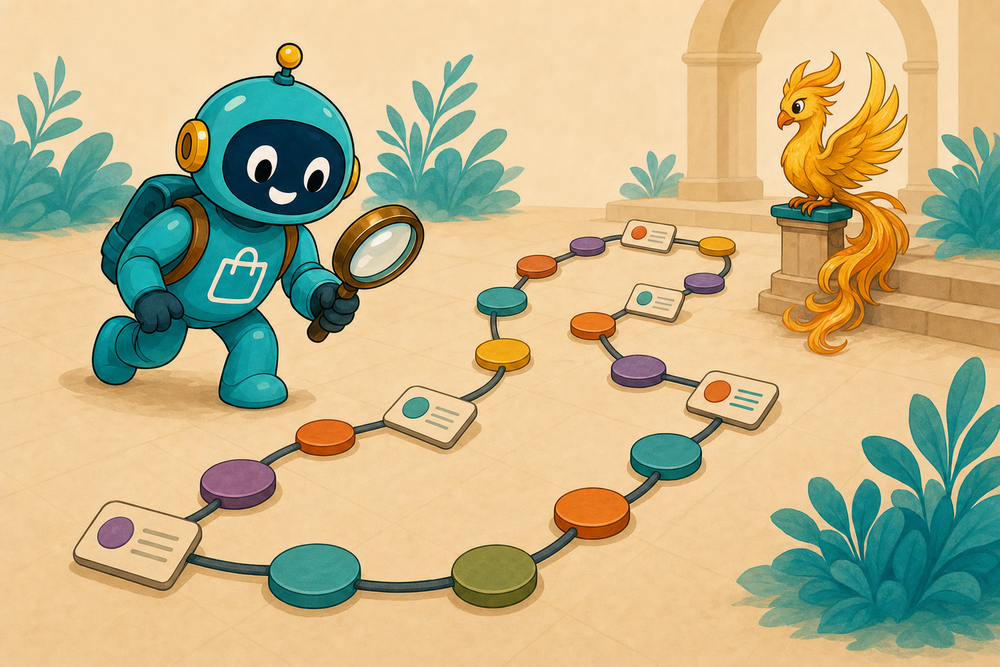

*Phoenix helps us follow each step of the Agent's journey.*

## Next Week

Today you built one agent and gave it a few Python tools. As a project grows, the four ideas below make the system easier to organize, extend, and keep safe. This is a short preview; there is no extra code to run in this notebook.

### Skills: package repeatable know-how 🧰

**What it is:** A Skill is a small bundle of instructions, examples, and procedures for one job.

Instead of putting every procedure in the Agent's main prompt, you can load the relevant Skill when it is needed.

**Why it helps:**

The Agent sees less unrelated context, and a procedure can be updated in one place.

**Today’s connection:** our order instructions are still written directly in the Agent.

A Skill could hold the order-support procedure later.

### MCP: connect to tools through a shared standard 🔌

**What it is:** MCP is a common way for an Agent to discover and call tools provided by another service.

The client does not need a custom REST wrapper for every service.

**Why it helps:**

Tools can be shared across many Agents and clients with a consistent interface.

**Today’s connection:** `tools_order.py` is our small, hand-written wrapper.

MCP could provide a standard remote version of that boundary.

### Subagents: give specialists their own focus 🧑‍🔧

**What it is:** A subagent is another Agent that handles one focused part of a larger task.

A main Agent can ask a specialist to do the work and then use the specialist's result.

**Why it helps:**

Each Agent has a smaller prompt and a clearer responsibility.

**Today’s connection:** a future system might use one specialist for order lookup and another for shipping questions.

### Guardrails: set safe boundaries 🛡️

**What it is:** Guardrails are checks around an Agent's inputs, outputs, and tool calls.

They can reject unsafe requests, stop unsupported claims, or make sure a tool receives valid arguments.

**Why it helps:**

The Agent has clear limits instead of relying only on a prompt to do the right thing.

**Today’s connection:** our instruction says to use service-returned order IDs and not invent details.

A guardrail could enforce those rules automatically.